In [1]:
import pandas as pd
import numpy as np
import scipy.stats
import seaborn as sns
import glob
import os.path as op
import os
from os.path import join, exists
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [2]:
## Set variables

subid_list = ['sub-001', 'sub-002', 'sub-003', 'sub-004']
# sub_uid = 'sub-004'

# toggle whether to look at all subregions of the fROI or just the overall languege network
# rois = {1:'LH_IFGorb', 2:'LH_IFG', 3:'LH_MFG', 4:'LH_AntTemp', 5:'LH_PostTemp', 6:'LH_AnG', 7:'RH_IFGorb', 8:'RH_IFG', 9:'RH_MFG', 10:'RH_AntTemp', 11:'RH_PostTemp', 12:'RH_AnG', 13: 'ALL'}
rois = {1: 'ALL'}

n_stimuli = 24

In [3]:
## Set paths

# change if running elsewhere 
path_to_parent_directory = '/Users/bianca/Desktop/NEU502B/neu502b_fmri'

path_to_stimsets = f'{path_to_parent_directory}/emotion_word_glmsingle/emotion_word_stim'

path_to_design_matrices = f'{path_to_parent_directory}/emotion_word_glmsingle/design_matrices'

path_to_emotion_word_glmsingle = f'{path_to_parent_directory}/emotion_word_glmsingle/output_betas'

path_to_behavioral_data = f'{path_to_parent_directory}/behavioral_task'
behavioral_data_filename = 'behavior_data.csv'

path_to_export_figs = f'{path_to_parent_directory}/output_figures'


In [4]:
# set up dictionary with correspondence between emotion word ids and words

# taking only from sub-001 because relevant information is the same across all subjects 
emotion_word_stim_file = f"{path_to_stimsets}/stimset_emotion_word_sub-001.csv"  
emotion_word_stimset = pd.read_csv(emotion_word_stim_file)

emotion_word_dict = {}

# extract word_ids and corresponding words from the emotion word stim file
for i in range(n_stimuli):
    
    # extract word id
    word_id = int(emotion_word_stimset.word_id[i])
    # print(word_id)

    # extract word label
    word_label = emotion_word_stimset.word[i]
    # print(word_label)

    emotion_word_dict[word_id] = word_label


# create new pandas table with just relevant word characteristics 
emotion_word_stim_table = emotion_word_stimset.loc[0:23, ['word_id', 'word', 'category_num', 'category_arousal', 'category_valence']]
emotion_word_stim_table["word_id"] = emotion_word_stim_table["word_id"].astype(int)
emotion_word_stim_table["category_num"] = emotion_word_stim_table["category_num"].astype(int)
# print(emotion_word_stim_table)
# print(len(emotion_word_stim_table))


# order with which to reorder by categories 
    # category 1 (high arousal, high valence)
    # category 4 (low arousal, high valuence)
    # category 2 (high arousal, low valence)
    # category 3 (low arousal, low valence)
reorder = [6, 15, 17, 18, 20, 21,   # high arousal, high valence
            2, 5, 8, 9, 11, 19,      # low arousal, high valence
            1, 3, 4, 7, 10, 12,      # high arousal, low valence
            0, 13, 14, 16, 22, 23]   # low arousal, low valence

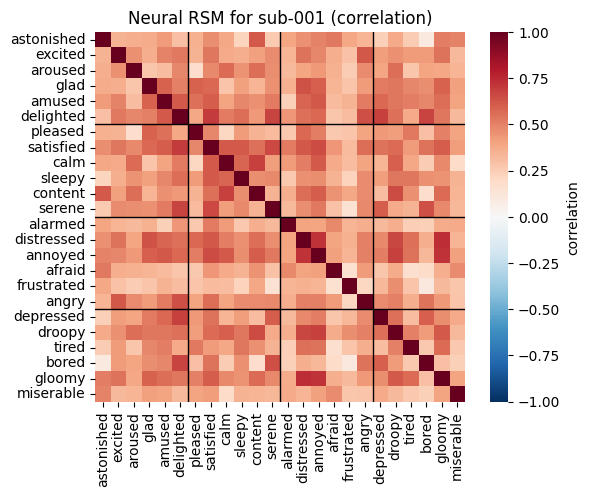

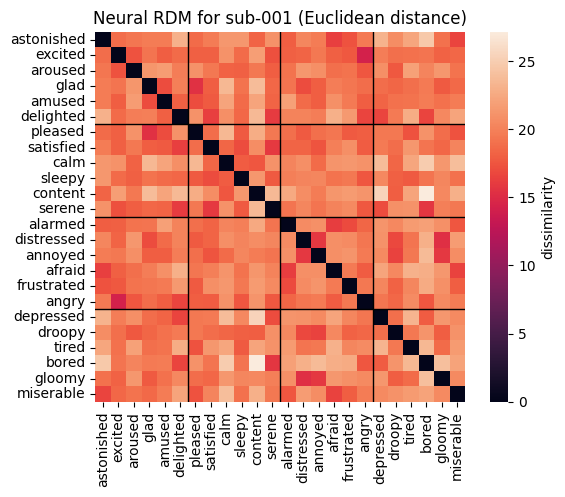

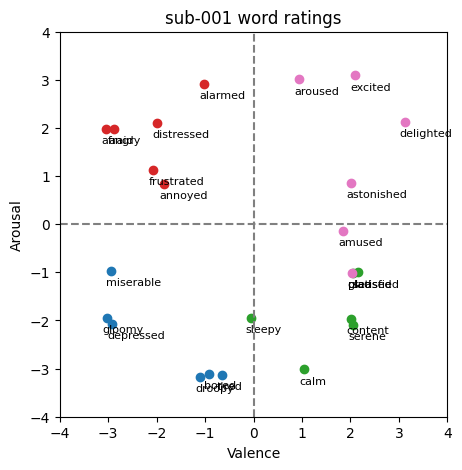

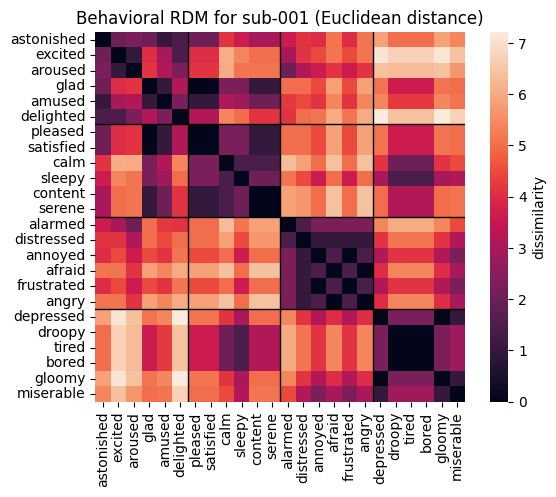

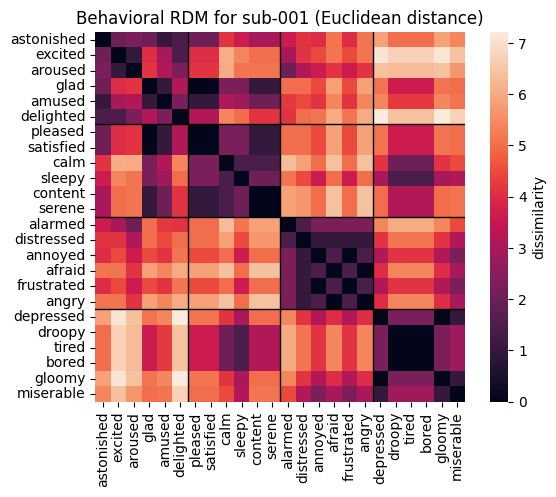

Spearman correlation between neural RDM (correlation) and behavioral RDM for sub-001 in ROI ALL: 0.018458171992083407
Spearman correlation between neural RDM (euclidean) and behavioral RDM for sub-001 in ROI ALL: 0.03060463339283195


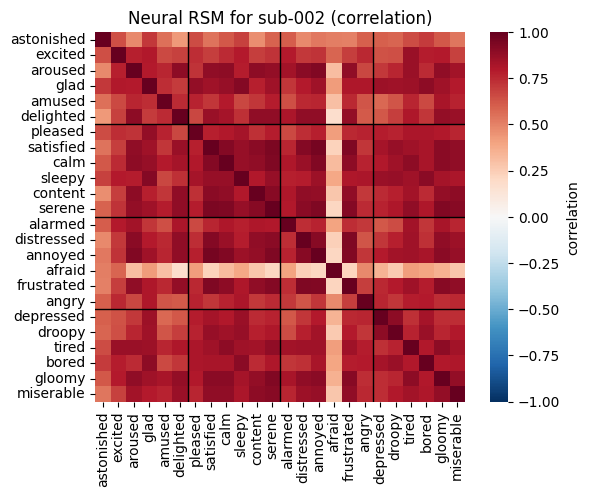

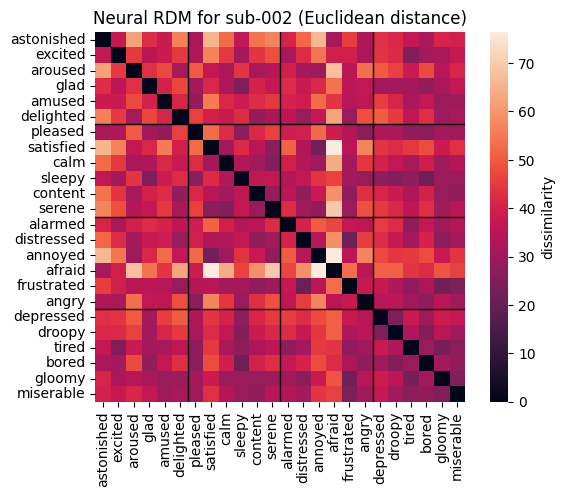

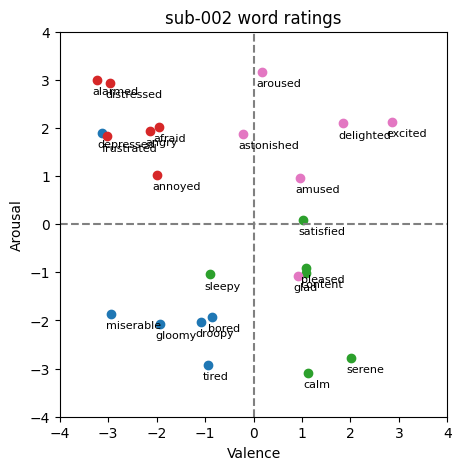

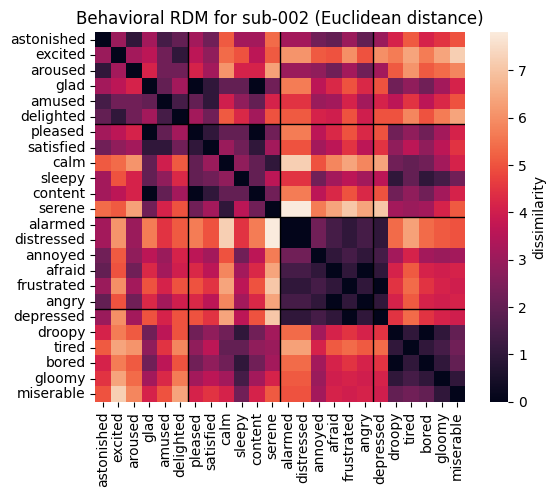

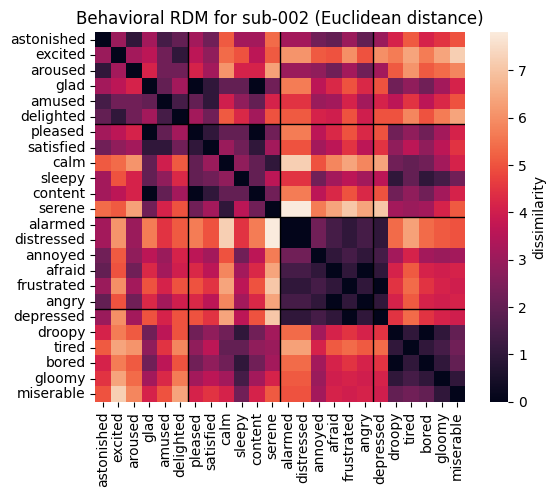

Spearman correlation between neural RDM (correlation) and behavioral RDM for sub-002 in ROI ALL: -0.026259832334962988
Spearman correlation between neural RDM (euclidean) and behavioral RDM for sub-002 in ROI ALL: -0.019813927709985468


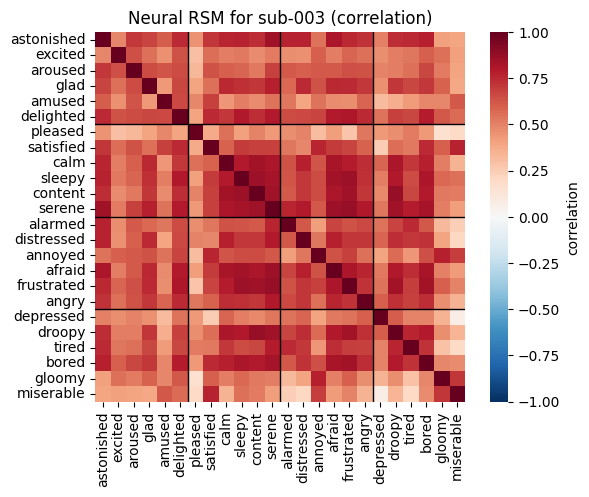

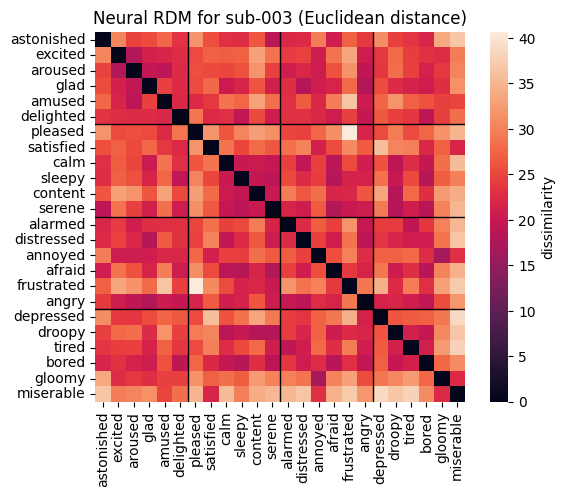

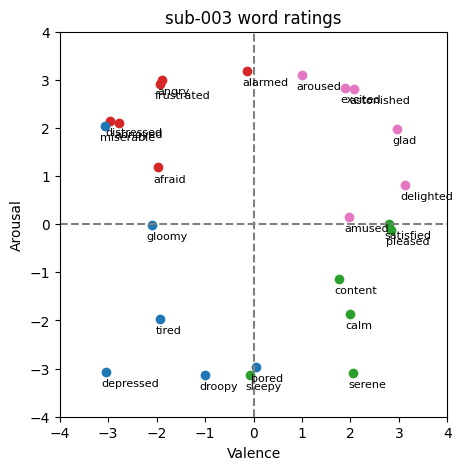

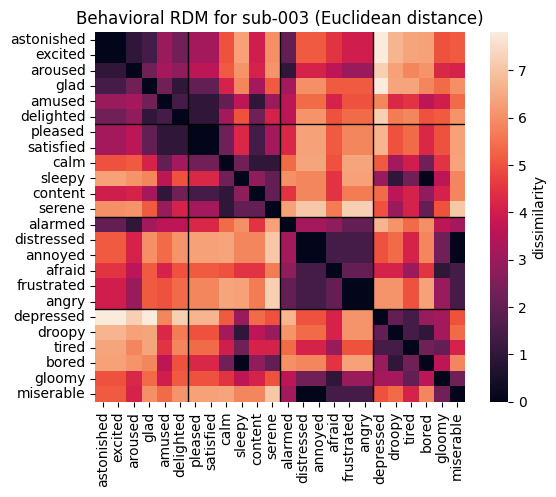

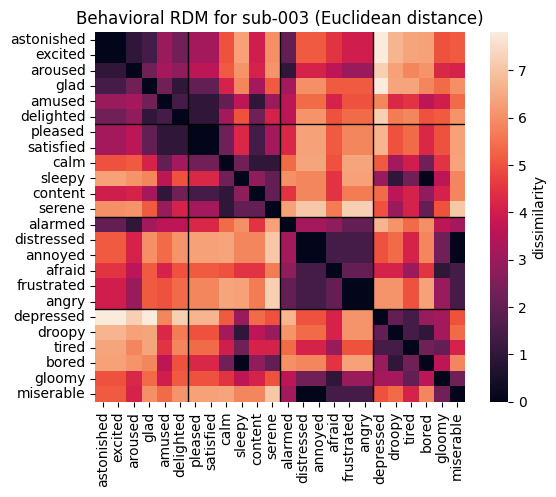

Spearman correlation between neural RDM (correlation) and behavioral RDM for sub-003 in ROI ALL: -0.0033662868055709906
Spearman correlation between neural RDM (euclidean) and behavioral RDM for sub-003 in ROI ALL: -0.006240531689472068


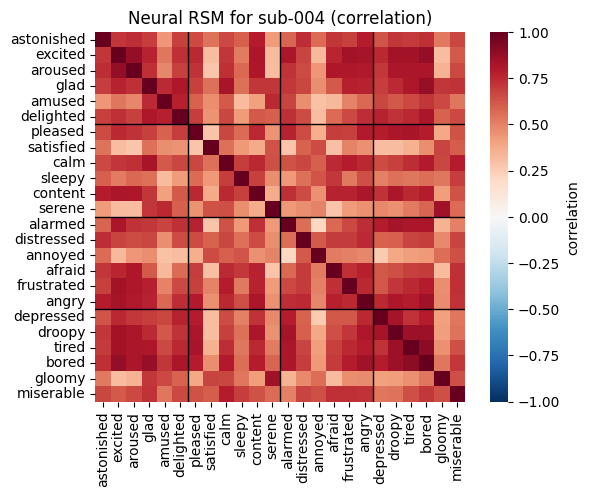

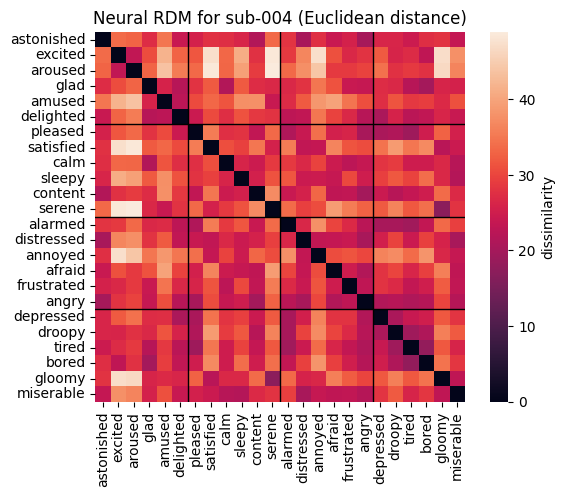

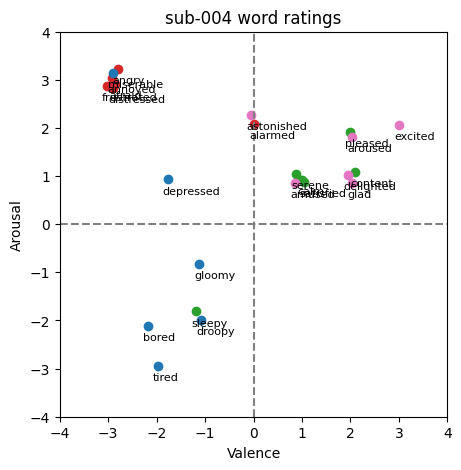

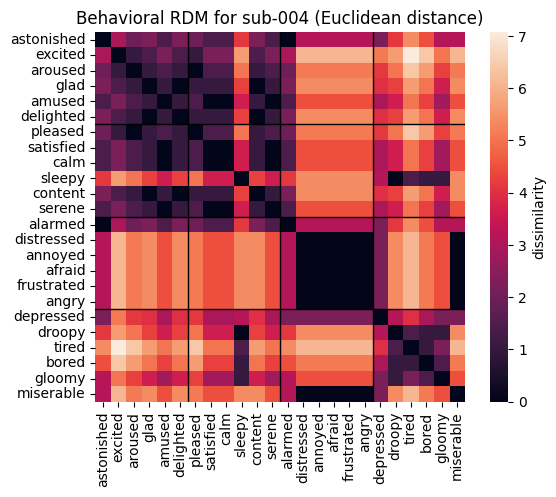

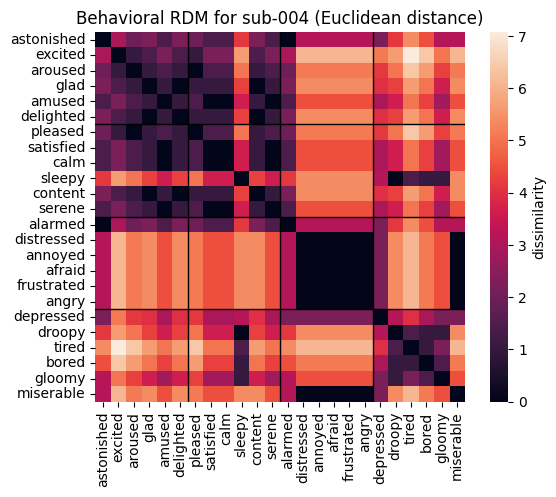

Spearman correlation between neural RDM (correlation) and behavioral RDM for sub-004 in ROI ALL: -0.10190871814162991
Spearman correlation between neural RDM (euclidean) and behavioral RDM for sub-004 in ROI ALL: -0.038461041584539044


In [6]:
### perform all relevant calculations for each subject, including  
## extracting beta values in each ROI of interest for each emotion word
## creating neural RDMs for each ROI 
## creating plot of behavioral ratings 
## creating behavioral RDM 
## and storing all outputs in relevant dictionaries so they can be accessed later 

# initialize storage dictionaries for betas and rdms
emotion_word_betas_dict = {}
neural_rdm_corr_dict = {}
neural_rdm_euclidean_dict = {}
behavioral_rdm_dict = {}

# read in behavioral data
behavioral_data_all = pd.read_csv(join(path_to_behavioral_data, behavioral_data_filename))

for sub_uid in subid_list:

    # add nested dictionaries as needed 
    emotion_word_betas_dict[sub_uid] = {}
    neural_rdm_corr_dict[sub_uid] = {}
    neural_rdm_euclidean_dict[sub_uid] = {}
    
    # set subject-specific paths
    path_to_emotion_word_results = f'{path_to_emotion_word_glmsingle}/{sub_uid}/average_item_betas'

    # initialize dictionary to keep track of flattened beta arrays to make rdm
    emotion_word_betas_lists = {}



    ## extract betas and add them to relevant dictionaries 
    for roi_num, roi_label in rois.items():

        emotion_word_betas_dict[sub_uid][roi_label] = {}
        emotion_word_betas_lists[roi_label] = []

        # set path to fROI-specific directory with npy files with emotion word  
        path_to_emotion_word_betas = f'{path_to_emotion_word_results}/{roi_label}'

        for emotion_word_id, emotion_word_label in emotion_word_dict.items():

            # extract numpy array with beta values for that word
            emotion_word_beta_filename = f'emotion_word_itemID_{emotion_word_id}_{roi_label}_average_item_betas.npy'
            emotion_word_betas = np.load(join(path_to_emotion_word_betas, emotion_word_beta_filename))

            # print(emotion_word_betas.shape)

            emotion_word_betas_flattened = emotion_word_betas.flatten()
            emotion_word_betas_flattened = emotion_word_betas_flattened[np.newaxis, :]
            emotion_word_betas_flattened = np.nan_to_num(emotion_word_betas_flattened)
            # print(emotion_word_betas_flattened.shape)
            
            # store numpy arrays in the dict of dicts and dict of lists 
            emotion_word_betas_dict[sub_uid][roi_label][word_label] = emotion_word_betas
            emotion_word_betas_lists[roi_label].append(emotion_word_betas_flattened)


        
    ## stack beta arrays and create neural rdms for each ROI
    # for each ROI 
    for roi_label, emotion_word_betas_list in emotion_word_betas_lists.items():

        # stack arrays for each word into a single master array 
        stacked_betas = np.vstack(emotion_word_betas_list)
        
        # compute rdm with correlation metric
        rdm_corr = pdist(stacked_betas, metric='correlation')
        neural_rdm_corr_dict[sub_uid][roi_label] = rdm_corr
        
        # compute rdm with euclidean distance metric
        rdm_euclidean = pdist(stacked_betas, metric='euclidean')
        neural_rdm_euclidean_dict[sub_uid][roi_label] = rdm_euclidean

        # source word labels
        word_labels = emotion_word_stim_table["word"]
        # print(word_labels)
        
        # print(word_labels[reorder])

        squareform_rdm_corr = squareform(rdm_corr)
        ax = sns.heatmap(1 - squareform_rdm_corr[reorder][:, reorder],  
                vmin = -1, vmax = 1, 
                cmap = 'RdBu_r',
                square = True, 
                xticklabels = word_labels[reorder],
                yticklabels = word_labels[reorder],
                cbar_kws = {'label': 'correlation'})
        for i in range(6, 24, 6):
            ax.axvline(i, color = 'black', lw = 1)
            ax.axhline(i, color = 'black', lw = 1)
        plt.title(f"Neural RSM for {sub_uid} (correlation)")
        plt.savefig(f'{path_to_export_figs}/neural_rdms/{sub_uid}_{roi_label}_neural_rdm_corr.png', 
                    bbox_inches='tight')
        plt.show()

        squareform_rdm_euclidean = squareform(rdm_euclidean)
        ax = sns.heatmap(squareform_rdm_euclidean[reorder][:, reorder],  
                # cmap = 'RdBu_r',
                square = True, 
                xticklabels = word_labels[reorder],
                yticklabels = word_labels[reorder],
                cbar_kws = {'label': 'dissimilarity'})
        for i in range(6, 24, 6):
            ax.axvline(i, color = 'black', lw = 1)
            ax.axhline(i, color = 'black', lw = 1)
        plt.title(f"Neural RDM for {sub_uid} (Euclidean distance)")
        plt.savefig(f'{path_to_export_figs}/neural_rdms/{sub_uid}_{roi_label}_neural_rdm_euclidean.png', 
                    bbox_inches='tight')
        plt.show()

    

    ## create behavioral figures 
    # import behavioral ratings for the subject 
    behavioral_data_sub = behavioral_data_all[behavioral_data_all['subid'] == sub_uid]
    # print(behavioral_data_sub)

    # for categories in order: 1, 2, 3, 4
    emotion_category_colors = ['tab:pink', 'tab:red','tab:blue','tab:green']

    jitter_value = 0.1

    # plot behavioral data 
    fig, ax = plt.subplots(figsize=(5, 5))
    for row in behavioral_data_sub.itertuples():
        valence_rating = row.valence_rating
        arousal_rating = row.arousal_rating
        word_label = row.word
        category_num = row.category_num
        category_color = emotion_category_colors[category_num - 1]

        jittered_valence = valence_rating + np.random.normal(loc = 0, scale = jitter_value)
        jittered_arousal = arousal_rating + np.random.normal(loc = 0, scale = jitter_value)

        ax.scatter(jittered_valence, jittered_arousal, c = category_color)
        ax.text(jittered_valence - 0.1, jittered_arousal - 0.3, word_label, fontsize = 8)
    ax.axhline(0, color='gray', linestyle='--')
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_xlabel('Valence')
    ax.set_ylabel('Arousal')
    ax.set_title(f'{sub_uid} word ratings')
    plt.savefig(f'{path_to_export_figs}/behavioral_ratings/{sub_uid}_behavioral_ratings.png', 
                    bbox_inches='tight')
    plt.show()



    ## create behavioral RDMs

    # build behavioral RDM manually
    behavioral_rdm = np.zeros((n_stimuli, n_stimuli))
    # compute euclidean distances manually 
    for i in range(n_stimuli): 
        word_id_i = i + 1 

        for j in range(n_stimuli):
            word_id_j = j + 1

            valence_i = behavioral_data_sub.loc[behavioral_data_sub["word_id"] == word_id_i, "valence_rating"].iloc[0]
            arousal_i = behavioral_data_sub.loc[behavioral_data_sub["word_id"] == word_id_i, "arousal_rating"].iloc[0]

            valence_j = behavioral_data_sub.loc[behavioral_data_sub["word_id"] == word_id_j, "valence_rating"].iloc[0]
            arousal_j = behavioral_data_sub.loc[behavioral_data_sub["word_id"] == word_id_j, "arousal_rating"].iloc[0]

            behavioral_rdm[i, j] = np.sqrt((valence_i - valence_j)**2 + (arousal_i - arousal_j)**2)


    # compute euclidean distances using pdist
    behavioral_ratings = np.array([behavioral_data_sub['valence_rating'], behavioral_data_sub['arousal_rating']])
    behavioral_ratings = np.transpose(behavioral_ratings)
    behavioral_rdm_pdist = pdist(behavioral_ratings, metric='euclidean')

    behavioral_rdm_dict[sub_uid] = behavioral_rdm_pdist

    # NOTE: the following two plotted RDMs should be exactly the same (just plotting to verify that they are)

    # plot behavioral RDM with manual euclidean distances
    ax = sns.heatmap(behavioral_rdm[reorder][:, reorder],  
            # vmin = -1, vmax = 1, 
            # cmap = 'RdBu_r',
            square = True, 
            xticklabels = word_labels[reorder],
            yticklabels = word_labels[reorder],
            cbar_kws = {'label': 'dissimilarity'})
    for i in range(6, 24, 6):
        ax.axvline(i, color = 'black', lw = 1)
        ax.axhline(i, color = 'black', lw = 1)
    plt.title(f"Behavioral RDM for {sub_uid} (Euclidean distance)")
    # plt.savefig(f'{path_to_export_figs}/behavioral_rdms/{sub_uid}_behavioral_rdm.png', 
    #             bbox_inches='tight')
    plt.show()

    # plot behavioral RDM with pdist euclidean distances
    ax = sns.heatmap(squareform(behavioral_rdm_pdist)[reorder][:, reorder],  
            # vmin = -1, vmax = 1, 
            # cmap = 'RdBu_r',
            square = True, 
            xticklabels = word_labels[reorder],
            yticklabels = word_labels[reorder],
            cbar_kws = {'label': 'dissimilarity'})
    for i in range(6, 24, 6):
        ax.axvline(i, color = 'black', lw = 1)
        ax.axhline(i, color = 'black', lw = 1)
    plt.title(f"Behavioral RDM for {sub_uid} (Euclidean distance)")
    plt.savefig(f'{path_to_export_figs}/behavioral_rdms/{sub_uid}_behavioral_rdm.png', 
                bbox_inches='tight')
    plt.show()



    ## compute correlations between behavioral and neural rdms 
    for roi_label in rois.values():

        neural_rdm_corr = neural_rdm_corr_dict[sub_uid][roi_label]
        spearman_r_corr = spearmanr(neural_rdm_corr, behavioral_rdm_pdist)[0]
        print(f"Spearman correlation between neural RDM (correlation) and behavioral RDM for {sub_uid} in ROI {roi_label}: {spearman_r_corr}")

        neural_rdm_euclidean = neural_rdm_euclidean_dict[sub_uid][roi_label]
        spearman_r_euclidean = spearmanr(neural_rdm_euclidean, behavioral_rdm_pdist)[0]
        print(f"Spearman correlation between neural RDM (euclidean) and behavioral RDM for {sub_uid} in ROI {roi_label}: {spearman_r_euclidean}")


